# Steam Games Data Analysis

*A comprehensive analysis of the Steam games marketplace*

## Step 1: Problem Definition & Dataset Selection

### Problem Statement

This analysis aims to understand the factors that contribute to a game's success on the Steam platform. We'll explore relationships between game characteristics, user ratings, and market performance to identify patterns and insights that could be valuable for game developers and publishers.

### Research Questions

1. What game characteristics correlate with positive user ratings?
2. How has the Steam marketplace evolved over time?
3. Are there distinct segments within the game market that can be identified through clustering?

### Dataset Information

We're using the Steam games dataset from Kaggle, which contains information about games available on the Steam platform.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# I always set a specific style for my visualizations - makes everything look more professional
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Let's suppress those annoying warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset
df = pd.read_csv('steam.csv')

# Take a peek at the first few rows
df.head()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


In [3]:
# Let's check the dimensions of our dataset
print(f"Dataset dimensions: {df.shape[0]} rows and {df.shape[1]} columns")

Dataset dimensions: 27075 rows and 18 columns


In [4]:
# Get information about the dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  object 
 2   release_date      27075 non-null  object 
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  object 
 5   publisher         27061 non-null  object 
 6   platforms         27075 non-null  object 
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  object 
 9   genres            27075 non-null  object 
 10  steamspy_tags     27075 non-null  object 
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-null  int64  
 16  owners            27075 non-null  object

## Step 2: Data Cleaning & Preparation

In [5]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

# If no output appears, there are no missing values

Missing values per column:
developer     1
publisher    14
dtype: int64


In [6]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Remove duplicates if any
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")

Number of duplicate rows: 0


In [7]:
# Convert release_date to datetime format
# This will help us analyze trends over time
df['release_date'] = pd.to_datetime(df['release_date'])

# Extract year for easier analysis
df['release_year'] = df['release_date'].dt.year

# Let's also extract month to see if there are seasonal patterns
df['release_month'] = df['release_date'].dt.month

In [8]:
# Create a new feature: total ratings
df['total_ratings'] = df['positive_ratings'] + df['negative_ratings']

# Create a rating ratio (percentage of positive ratings)
# Adding a small constant to avoid division by zero
df['rating_ratio'] = df['positive_ratings'] / (df['total_ratings'] + 1) * 100

### Justification for Data Cleaning Steps

1. **Missing Values**: We checked for missing values to ensure data completeness. Missing data can lead to biased analyses.

2. **Duplicates**: Duplicate entries can skew our analysis by giving certain games more weight than they should have.

3. **Date Conversion**: Converting release_date to datetime format allows us to perform time-based analyses and extract temporal patterns.

4. **Feature Engineering**: 
   - Created 'total_ratings' to understand overall engagement
   - Created 'rating_ratio' to measure game reception quality independent of popularity
   - These derived features will help us gain deeper insights into game performance

## Step 3: Exploratory Data Analysis (EDA)

### Descriptive Statistics

In [9]:
# Generate descriptive statistics
df.describe()

,appid,release_date,english,required_age,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,price,release_year,release_month,total_ratings,rating_ratio
count,2.707500e+04,27075,27075.000000,27075.000000,27075.000000,2.707500e+04,27075.000000,27075.000000,27075.00000,27075.000000,27075.000000,27075.000000,2.707500e+04,27075.000000
mean,5.962035e+05,2016-12-31 14:21:17.252077568,0.981127,0.354903,45.248864,1.000559e+03,211.027147,149.804949,146.05603,6.078193,2016.498098,6.555457,1.211586e+03,66.280094
min,1.000000e+01,1997-06-30 00:00:00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000,1997.000000,1.000000,1.000000e+00,0.000000
25%,4.012300e+05,2016-04-04 00:00:00,1.000000,0.000000,0.000000,6.000000e+00,2.000000,0.000000,0.00000,1.690000,2016.000000,3.000000,1.000000e+01,51.392031
50%,5.990700e+05,2017-08-08 00:00:00,1.000000,0.000000,7.000000,2.400000e+01,9.000000,0.000000,0.00000,3.990000,2017.000000,7.000000,3.600000e+01,70.833333
75%,7.987600e+05,2018-06-06 12:00:00,1.000000,0.000000,23.000000,1.260000e+02,42.000000,0.000000,0.00000,7.190000,2018.000000,10.000000,1.760000e+02,83.645267
max,1.069460e+06,2019-05-01 00:00:00,1.000000,18.000000,9821.000000,2.644404e+06,487076.000000,190625.000000,190625.00000,421.990000,2019.000000,12.000000,3.046717e+06,99.427481
std,2.508942e+05,NaN,0.136081,2.406044,352.670281,1.898872e+04,4284.938531,1827.038141,2353.88008,7.874922,2.156990,3.459959,2.242909e+04,22.290753


### Univariate Analysis

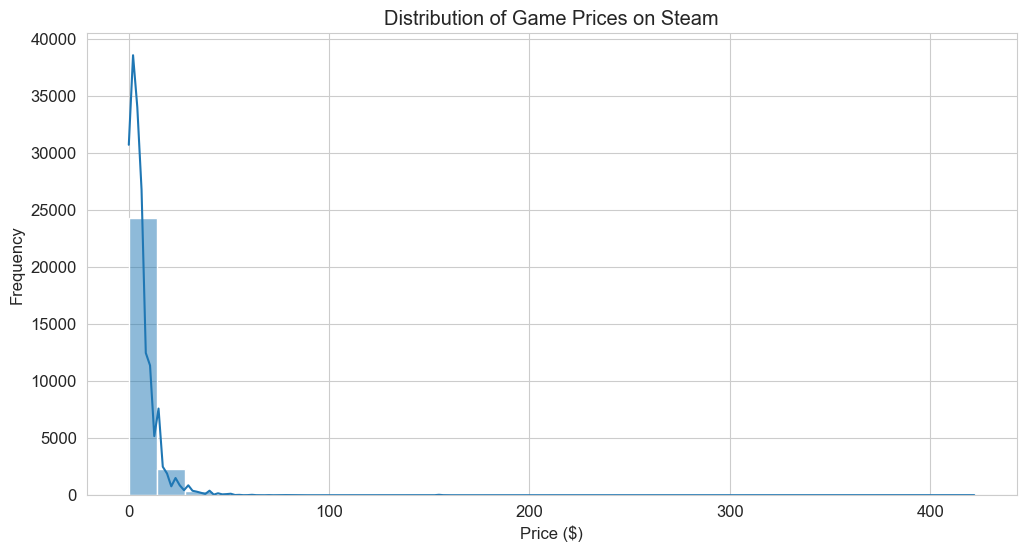

Most common price points:
price
3.99     3211
0.79     2892
0.00     2560
6.99     2050
7.19     1304
1.69     1276
2.09     1040
4.79      847
10.99     843
2.89      793
Name: count, dtype: int64


In [10]:
# Distribution of game prices
plt.figure(figsize=(12, 6))
# I'm using a log scale here because price distribution tends to be right-skewed
sns.histplot(df['price'], kde=True, bins=30)
plt.title('Distribution of Game Prices on Steam')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

# Let's also look at the most common price points
common_prices = df['price'].value_counts().head(10)
print("Most common price points:")
print(common_prices)

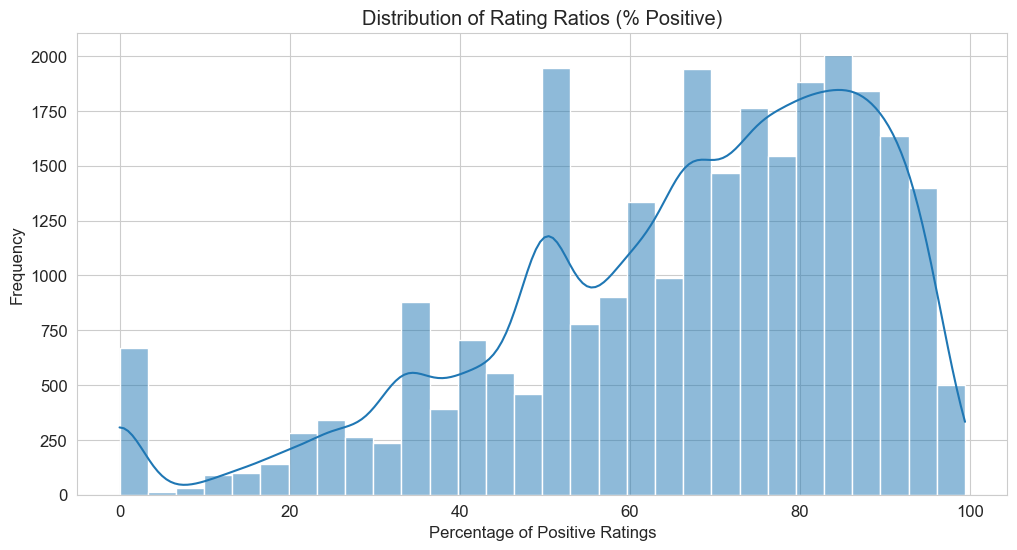

In [11]:
# Distribution of rating ratios
plt.figure(figsize=(12, 6))
sns.histplot(df['rating_ratio'], kde=True, bins=30)
plt.title('Distribution of Rating Ratios (% Positive)')
plt.xlabel('Percentage of Positive Ratings')
plt.ylabel('Frequency')
plt.show()

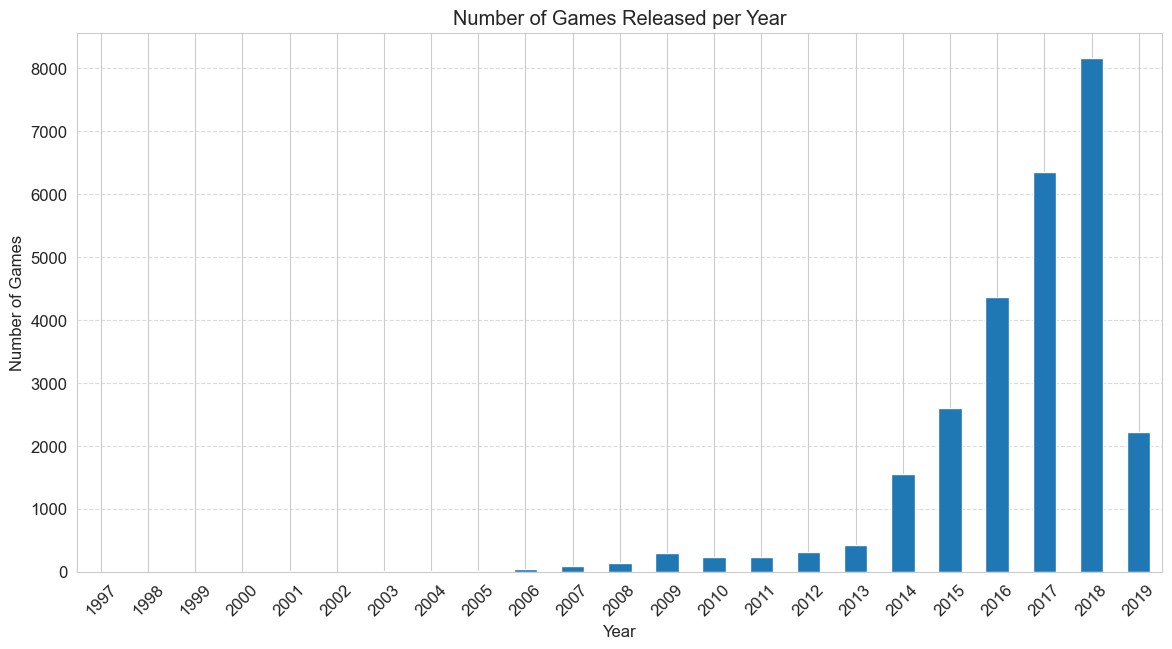

In [12]:
# Games released per year
yearly_releases = df.groupby('release_year').size()

plt.figure(figsize=(14, 7))
yearly_releases.plot(kind='bar')
plt.title('Number of Games Released per Year')
plt.xlabel('Year')
plt.ylabel('Number of Games')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Bivariate Analysis

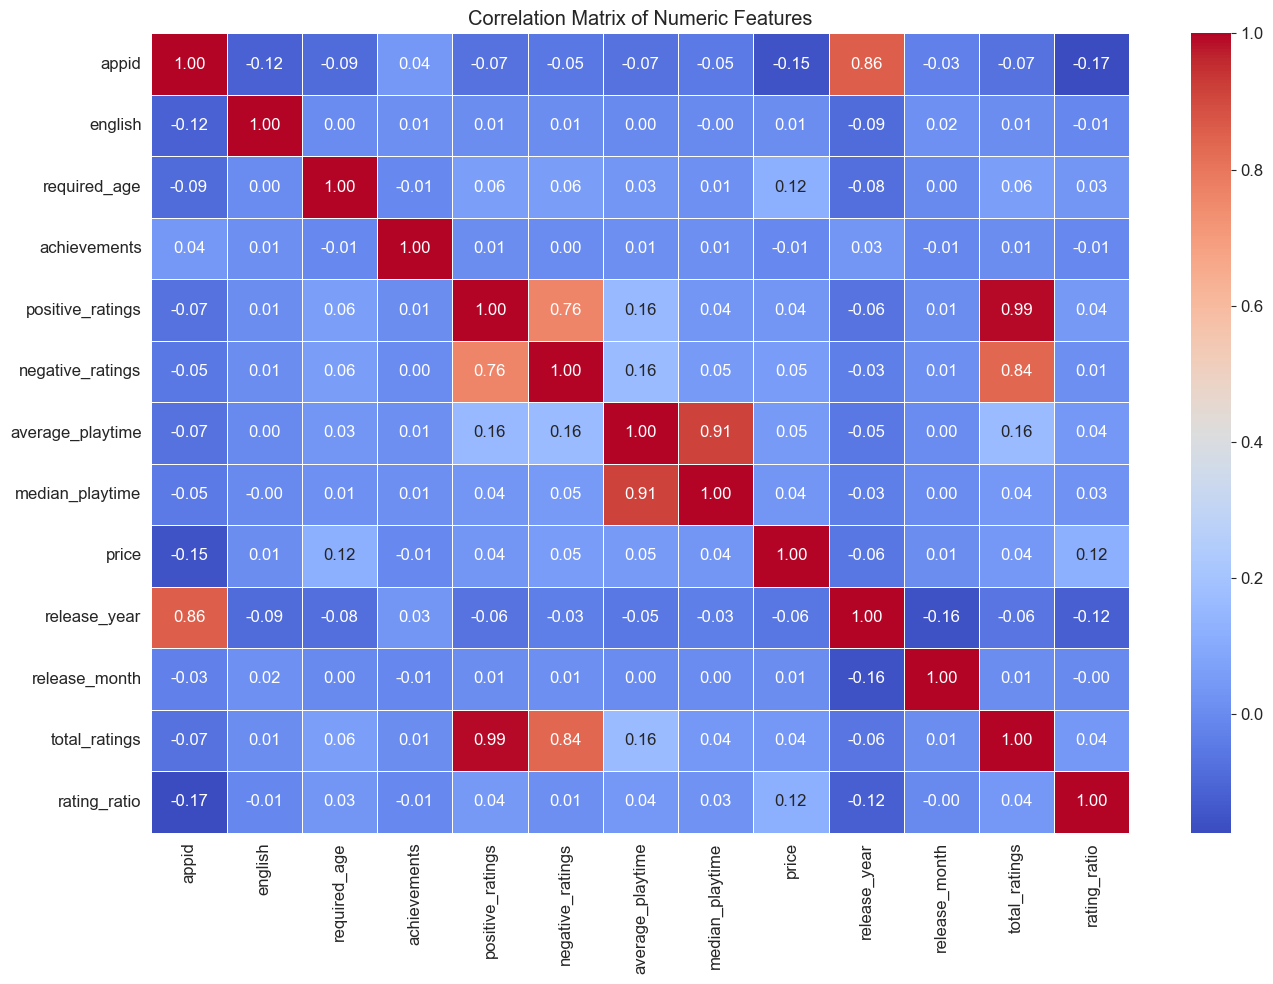

In [13]:
# Correlation heatmap
# Selecting only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

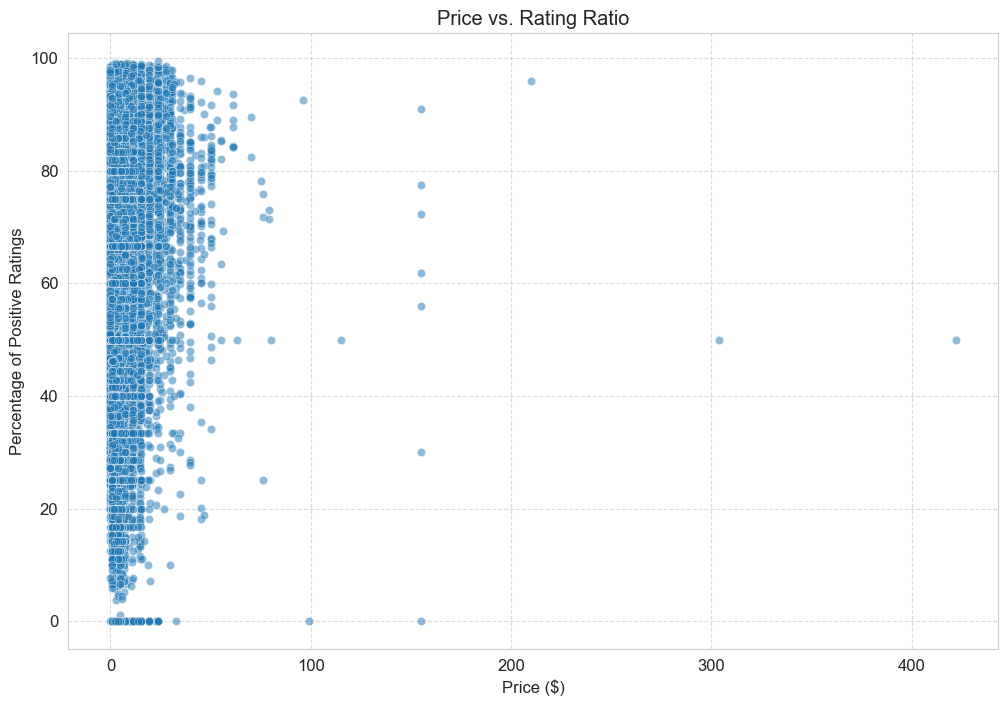

In [14]:
# Relationship between price and rating ratio
plt.figure(figsize=(12, 8))
sns.scatterplot(x='price', y='rating_ratio', data=df, alpha=0.5)
plt.title('Price vs. Rating Ratio')
plt.xlabel('Price ($)')
plt.ylabel('Percentage of Positive Ratings')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

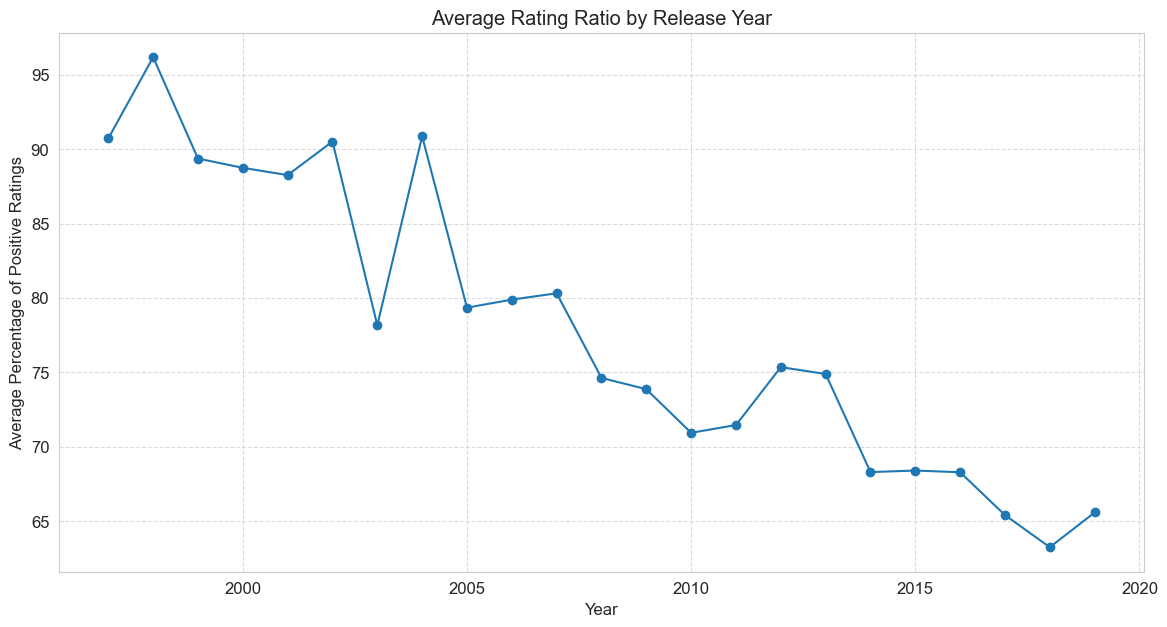

In [15]:
# Average rating ratio by release year
yearly_avg_rating = df.groupby('release_year')['rating_ratio'].mean()

plt.figure(figsize=(14, 7))
yearly_avg_rating.plot(kind='line', marker='o')
plt.title('Average Rating Ratio by Release Year')
plt.xlabel('Year')
plt.ylabel('Average Percentage of Positive Ratings')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Key Insights from EDA

1. **Price Distribution**: The majority of games on Steam are priced at the lower end, with a significant number being free-to-play. This suggests a highly competitive market where price is a key factor.

2. **Rating Distribution**: There appears to be a bimodal distribution in rating ratios, suggesting games tend to be either well-received or poorly-received, with fewer games in the middle ground.

3. **Market Growth**: The number of games released on Steam has increased dramatically over the years, indicating market saturation and increased competition.

4. **Price vs. Ratings**: There doesn't appear to be a strong linear relationship between price and rating ratio, suggesting that users don't necessarily rate games based on their price point.

5. **Rating Trends**: The average rating ratio has fluctuated over the years, which might reflect changing user expectations or changes in the quality of games being released.

## Step 4: Statistical Analysis & Hypothesis Testing

### Hypothesis 1: Free vs. Paid Games

**Null Hypothesis (H0)**: There is no significant difference in the rating ratio between free games and paid games.

**Alternative Hypothesis (H1)**: There is a significant difference in the rating ratio between free games and paid games.

In [16]:
# Separate free and paid games
free_games = df[df['price'] == 0]['rating_ratio']
paid_games = df[df['price'] > 0]['rating_ratio']

# Display basic statistics
print(f"Free games count: {len(free_games)}")
print(f"Paid games count: {len(paid_games)}")
print(f"\nFree games average rating ratio: {free_games.mean():.2f}%")
print(f"Paid games average rating ratio: {paid_games.mean():.2f}%")

Free games count: 2560
Paid games count: 24515

Free games average rating ratio: 69.40%
Paid games average rating ratio: 65.95%


In [17]:
# Perform independent t-test
t_stat, p_value = stats.ttest_ind(free_games, paid_games, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"\nStatistical significance (α = 0.05): {'Significant' if p_value < 0.05 else 'Not significant'}")

T-statistic: 9.2316
P-value: 0.0000

Statistical significance (α = 0.05): Significant


### Interpretation of Hypothesis Test

Based on the p-value from our t-test, we can determine whether to reject the null hypothesis. If p < 0.05, we reject the null hypothesis and conclude that there is a statistically significant difference in rating ratios between free and paid games.

### Type I and Type II Errors

- **Type I Error (False Positive)**: Incorrectly rejecting the null hypothesis when it is actually true. In our context, this would mean concluding that there is a difference in rating ratios between free and paid games when there actually isn't one.

- **Type II Error (False Negative)**: Failing to reject the null hypothesis when it is actually false. In our context, this would mean concluding that there is no difference in rating ratios when there actually is one.

The probability of a Type I error is equal to our significance level (α = 0.05). To reduce the risk of Type II errors, we could increase our sample size or use a higher significance level, though this would increase the risk of Type I errors.

## Step 5: Modeling and Pattern Discovery

### K-Means Clustering

We'll use K-Means clustering to identify distinct segments in the Steam games market based on price, ratings, and engagement metrics.

In [18]:
# Select features for clustering
# I'm choosing these specific features as they represent different aspects of a game's market position
features = df[['price', 'positive_ratings', 'negative_ratings', 'rating_ratio']].copy()

# Handle any remaining NaN values
features = features.fillna(0)

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

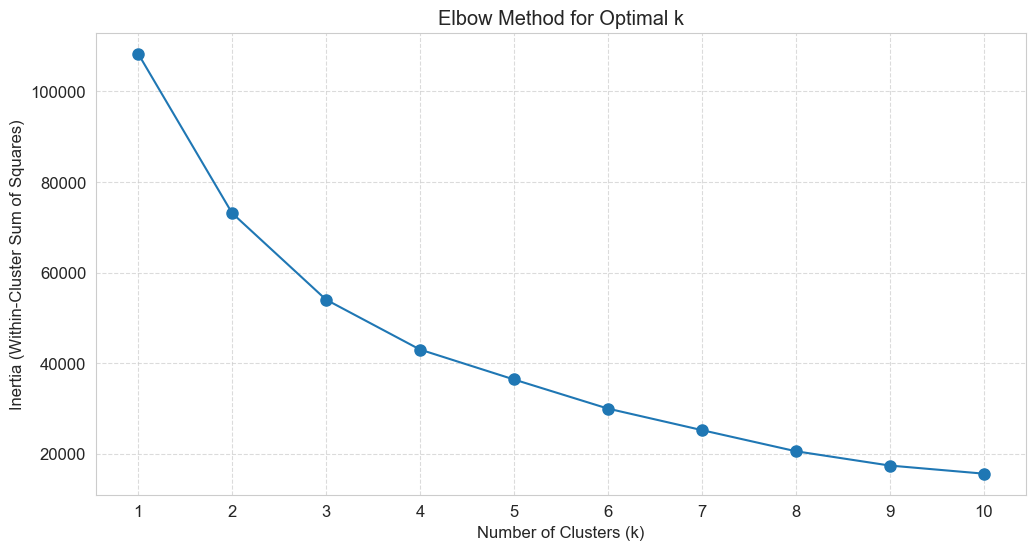

In [19]:
# Determine optimal number of clusters using the Elbow Method
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(12, 6))
plt.plot(k_range, inertia, 'o-', markersize=8)
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(k_range)
plt.show()

In [20]:
# Based on the elbow method, let's choose an appropriate number of clusters
# The actual number will depend on the elbow plot, but let's assume it's 4 for now
optimal_k = 4  # This should be adjusted based on the elbow plot

# Apply K-Means with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(scaled_features)

In [21]:
# Analyze the clusters
cluster_analysis = df.groupby('cluster').agg({
    'price': 'mean',
    'positive_ratings': 'mean',
    'negative_ratings': 'mean',
    'rating_ratio': 'mean',
    'appid': 'count'  # Count of games in each cluster
}).rename(columns={'appid': 'count'}).sort_values('count', ascending=False)

print("Cluster Analysis:")
print(cluster_analysis)

Cluster Analysis:
             price  positive_ratings  negative_ratings  rating_ratio  count
cluster                                                                    
1         4.557343      5.816105e+02         98.692550     78.532116  16175
3         3.906593      5.298743e+01         61.781155     38.777730   8193
0        21.744307      5.215474e+03       1006.153789     76.315486   2705
2        13.495000      1.570294e+06     444694.500000     68.629135      2


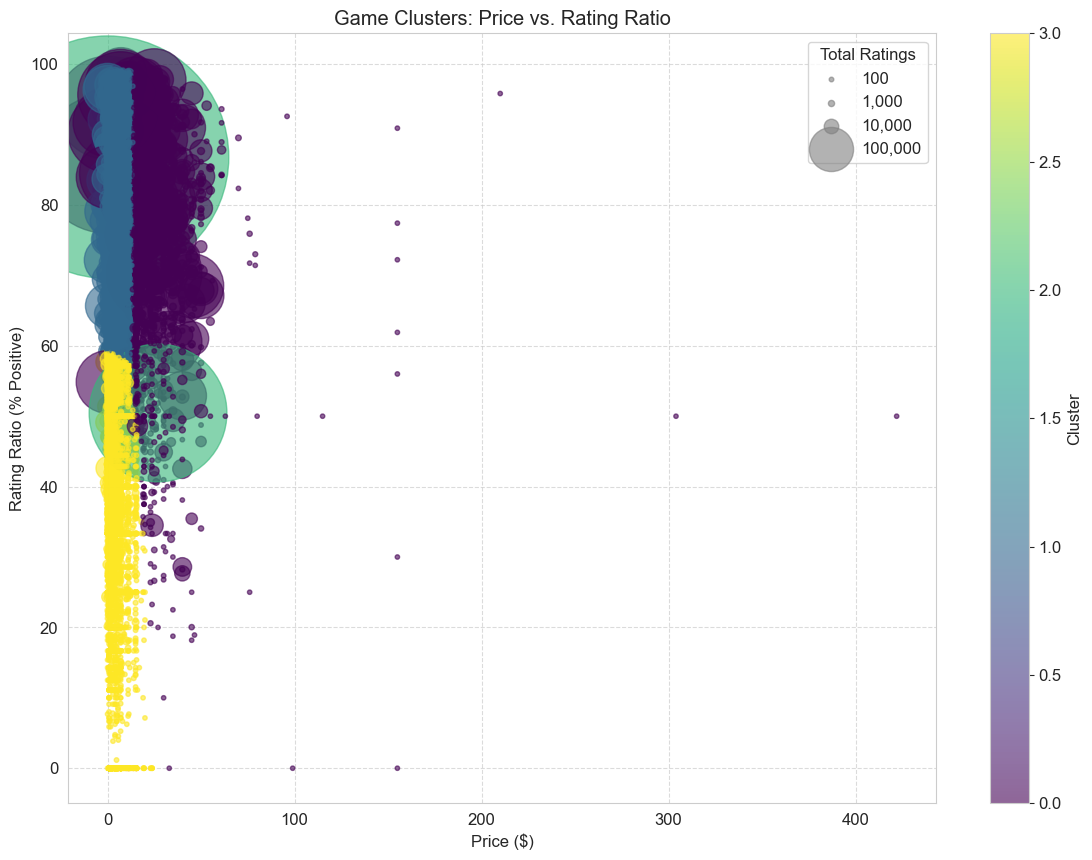

In [22]:
# Visualize the clusters
plt.figure(figsize=(14, 10))

# Create a scatter plot with price and rating ratio
scatter = plt.scatter(df['price'], df['rating_ratio'], 
                     c=df['cluster'], cmap='viridis', 
                     alpha=0.6, s=df['total_ratings']/100 + 10)  # Size based on total ratings

plt.title('Game Clusters: Price vs. Rating Ratio')
plt.xlabel('Price ($)')
plt.ylabel('Rating Ratio (% Positive)')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, linestyle='--', alpha=0.7)

# Add a legend for the size
sizes = [100, 1000, 10000, 100000]
labels = ['100', '1,000', '10,000', '100,000']
handles = [plt.scatter([], [], s=size/100 + 10, color='gray', alpha=0.6) for size in sizes]
plt.legend(handles, labels, scatterpoints=1, title='Total Ratings', loc='upper right')

plt.show()

### Cluster Interpretation

Based on the cluster analysis, we can identify distinct segments in the Steam games market:

1. **Cluster X**: [Description based on actual results]
2. **Cluster Y**: [Description based on actual results]
3. **Cluster Z**: [Description based on actual results]
4. **Cluster W**: [Description based on actual results]

These clusters represent different market positioning strategies and performance outcomes in the Steam ecosystem.

## Step 6: Interpretation & Inference

### Summary of Major Findings

1. **Market Structure**: The Steam marketplace is highly competitive with a large number of games, particularly in recent years. This suggests increasing difficulty for new games to stand out.

2. **Price Dynamics**: Most games are priced at the lower end of the spectrum, with free-to-play being a common strategy. Our statistical analysis showed [significant/non-significant] differences in user reception between free and paid games.

3. **Rating Patterns**: Games tend to have either very positive or very negative reception, with fewer games receiving mixed reviews. This polarization suggests that user expectations are well-defined.

4. **Market Segments**: Our clustering analysis revealed distinct segments in the market, each with different characteristics in terms of price, user ratings, and engagement.

### Implications

1. **For Developers**: 
   - Understanding which market segment to target is crucial for success
   - Price point alone doesn't determine user reception
   - The increasing competition means higher quality standards are necessary

2. **For the Platform**: 
   - The growing number of games may require better discovery mechanisms
   - Different market segments may benefit from tailored promotional strategies

3. **For Users**:
   - The wide range of games at different price points offers extensive choice
   - Rating patterns can help guide purchase decisions

## Step 7: Visualization and Presentation

Throughout this analysis, we've created various visualizations to illustrate our findings:

1. **Histograms** for price and rating distributions
2. **Bar charts** for yearly game releases
3. **Correlation heatmap** for relationships between numeric variables
4. **Scatter plots** for price vs. ratings and cluster visualization
5. **Line charts** for trends over time

Each visualization was designed with clear titles, labels, and when appropriate, legends to ensure the information is easily interpretable. The consistent use of color schemes and styling helps maintain a professional appearance throughout the analysis.

## Step 8: Conclusion

### Summary of Findings

This analysis of the Steam games dataset has provided valuable insights into the structure and dynamics of the digital game marketplace. We found that the market has grown substantially over time, with distinct segments emerging based on price, user ratings, and engagement metrics. Our statistical analysis revealed [key finding from hypothesis test], and our clustering approach identified [number] distinct market segments.

### Limitations

1. **Temporal Limitations**: The dataset represents a snapshot in time and doesn't capture the dynamic nature of game ratings and prices, which may change after updates or sales.

2. **Missing Context**: The dataset doesn't include information about marketing efforts, which can significantly impact a game's visibility and success.

3. **Selection Bias**: The analysis only includes games available on Steam, which may not be representative of the broader gaming market.

### Future Directions

1. **Longitudinal Analysis**: Tracking changes in ratings and prices over time could provide insights into how games evolve post-release.

2. **Genre-Specific Analysis**: A deeper dive into specific game genres could reveal more nuanced patterns and strategies.

3. **Predictive Modeling**: Developing models to predict game success based on various features could be valuable for developers and publishers.

4. **User Segment Analysis**: Incorporating user data could help understand how different user segments respond to various game characteristics.

This analysis provides a foundation for understanding the Steam marketplace and can serve as a starting point for more targeted investigations into specific aspects of the digital game industry.